In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from PIL import Image

In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

In [14]:

def generate_bbox_mask(image_size, bbox):
    """
    Generate a mask with 1 inside the bounding box and 0 outside.
    
    Parameters:
    - image_size: Tuple representing the size of the image (height, width)
    - bbox: Bounding box coordinates in the form (x_min, y_min, x_max, y_max)
    
    Returns:
    - mask: A 2D numpy array (mask) with 1 inside the bounding box and 0 outside.
    """
    # Initialize an empty mask with zeros (background)
    mask = np.zeros(image_size, dtype=np.uint8)
    
    # Unpack bbox coordinates
    x_min, y_min, x_max, y_max = bbox
    
    # Set pixels inside the bounding box to 1 (or any object label)
    mask[y_min:y_max, x_min:x_max] = 1
    
    return mask

In [15]:


class BBoxSegmentationDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, img_size=(512, 512)):
        
        self.annotations = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.img_size = img_size
        self.transform = transforms.Compose([
                    transforms.Resize(size=img_size),
                    transforms.ToTensor(),
                    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                ]) if transform is None else transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        # Get the image information from the CSV
        row = self.annotations.iloc[index]
        img_name = row['image_id'] + '.png'  # Assuming images are in jpg format
        img_path = os.path.join(self.root_dir, img_name)
        
        # Load the image
        image = Image.open(img_path).convert('RGB')

        # Get bounding box coordinates and class label
        bbox = torch.tensor([row['x_min'], row['y_min'], row['x_max'], row['y_max']], dtype=torch.float32)
        class_id = torch.tensor(row['class_id'], dtype=torch.long)
        
        # Create an empty mask with the same size as the image
        #mask = np.zeros((self.img_size[1], self.img_size[0]), dtype=np.uint8)  # (height, width)

        # Calculate the bounding box (and ensure the values are within image bounds)
        x_min = int(bbox[0] / image.width * self.img_size[0])
        y_min = int(bbox[1] / image.height * self.img_size[1])
        x_max = int(bbox[2] / image.width * self.img_size[0])
        y_max = int(bbox[3] / image.height * self.img_size[1])

        # Set the mask to 1 inside the bounding box (or set it to class_id for multi-class segmentation)
        #mask[y_min:y_max, x_min:x_max] = 1  # You can replace `1` with `class_id` for class-wise segmentation

        # Convert mask to tensor
        mask = generate_bbox_mask((self.img_size[1], self.img_size[0]), (x_min, y_min, x_max, y_max))

        # Apply transformations to the image
        if self.transform:
            image = self.transform(image)

        # Return image, mask, and class label
        return image, mask, class_id


In [16]:
csv_file = 'vindr/vindr_val.csv'
root_dir = '/data6/rajivporana_scratch/vindr_data/png_train'
dataset = BBoxSegmentationDataset(csv_file=csv_file, root_dir=root_dir)

# To use it with a DataLoader
from torch.utils.data import DataLoader
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# Iterate through the DataLoader
count =0
for images, bboxes, class_ids in dataloader:
    print(images.shape, bboxes.shape, class_ids.shape)
    count +=1
    if count == 2:
        break


torch.Size([16, 3, 512, 512]) torch.Size([16, 512, 512]) torch.Size([16])
torch.Size([16, 3, 512, 512]) torch.Size([16, 512, 512]) torch.Size([16])


In [17]:
img,mask,class_id = next(iter(dataloader))

print(img.shape, mask.shape, class_id.shape)

torch.Size([16, 3, 512, 512]) torch.Size([16, 512, 512]) torch.Size([16])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


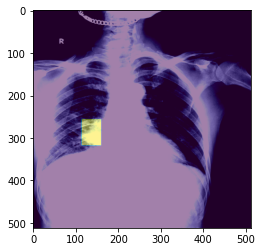

In [24]:
plt.imshow(img[0].permute(1, 2, 0))
plt.imshow(mask[0],alpha=0.5)
plt.show()